# DL Experiments - улучшение baseline

## План экспериментов

В ноутбуке сравниваются:

1. Baseline: ResNet-18 с замороженным backbone и лёгкими аугментациями.
2. ResNet-18 + stronger augmentation: усиленные аугментации.
3. ResNet-18 fine-tuning: разморозка последнего блока backbone.
4. MobileNetV2: лёгкая transfer learning модель.
5. EfficientNet-B0: более современная CNN-архитектура.

Для каждого эксперимента фиксируются модель, гиперпараметры, аугментации, Accuracy, Macro F1, ROC-AUC macro и время обучения.

In [ ]:
import os
import time
import copy
import random
import warnings
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

In [ ]:
INPUT_ROOT = Path("/kaggle/input/datasets/ivancloudmalyshev/project/project1_ML")
ROOT = Path("/kaggle/working/datasets/ivancloudmalyshev/project/project1_ML")
RAW_DIR = INPUT_ROOT / "data" / "raw"
IMG_DIR = RAW_DIR / "images"
SPLITS_DIR = INPUT_ROOT / "data" / "splits"
RESULTS_DIR = ROOT / "results"
MODELS_DIR = ROOT / "models"
PLOTS_DIR = ROOT / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 10
SAMPLE_FRACTION = 1.0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)
print("ROOT:", ROOT)
print("IMG_DIR:", IMG_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
assert IMG_DIR.exists(), f"Не найдена папка изображений: {IMG_DIR}"
assert (SPLITS_DIR / "train.csv").exists(), f"Не найден train.csv: {SPLITS_DIR / 'train.csv'}"
assert (SPLITS_DIR / "val.csv").exists(), f"Не найден val.csv: {SPLITS_DIR / 'val.csv'}"
assert (SPLITS_DIR / "test.csv").exists(), f"Не найден test.csv: {SPLITS_DIR / 'test.csv'}"

DEVICE: cuda
ROOT: /kaggle/working/datasets/ivancloudmalyshev/project/project1_ML
IMG_DIR: /kaggle/input/datasets/ivancloudmalyshev/project/project1_ML/data/raw/images
SPLITS_DIR: /kaggle/input/datasets/ivancloudmalyshev/project/project1_ML/data/splits


## Загрузка данных

In [ ]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
display(train_df.head())

def make_image_path(image_name):
    image_name = str(image_name)
    if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
        image_name = image_name + ".jpg"
    return str(IMG_DIR / image_name)

for df_part in [train_df, val_df, test_df]:
    df_part["image_path"] = df_part["image"].apply(make_image_path)

if "y" in train_df.columns:
    for df_part in [train_df, val_df, test_df]:
        df_part["target"] = df_part["y"].astype(int)
else:
    classes = sorted(train_df["label"].astype(str).unique())
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    for df_part in [train_df, val_df, test_df]:
        df_part["label"] = df_part["label"].astype(str)
        df_part["target"] = df_part["label"].map(class_to_idx).astype(int)

if SAMPLE_FRACTION < 1.0:
    train_df = train_df.groupby("target", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * SAMPLE_FRACTION)), random_state=SEED)
    ).reset_index(drop=True)
    val_df = val_df.groupby("target", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * SAMPLE_FRACTION)), random_state=SEED)
    ).reset_index(drop=True)
    test_df = test_df.groupby("target", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * SAMPLE_FRACTION)), random_state=SEED)
    ).reset_index(drop=True)

classes_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

if "label" in classes_df.columns:
    label_map = (
        classes_df[["target", "label"]]
        .drop_duplicates()
        .sort_values("target")
    )
    classes = label_map["label"].astype(str).tolist()
else:
    classes = [str(i) for i in sorted(classes_df["target"].unique())]

class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for i, cls in enumerate(classes)}

for name, df_part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    found = df_part["image_path"].apply(lambda x: Path(x).exists()).sum()
    print(f"{name}: найдено изображений {found} из {len(df_part)}")

print("Классы:", classes)
print("Train distribution:")
print(train_df["target"].value_counts(normalize=True).sort_index().round(3))

train: (7010, 4)
val: (1502, 4)
test: (1503, 4)


,image,label,path,y
0,ISIC_0031775.jpg,nv,/content/drive/MyDrive/project1_ML/data/raw/im...,5
1,ISIC_0027306.jpg,mel,/content/drive/MyDrive/project1_ML/data/raw/im...,4
2,ISIC_0033895.jpg,nv,/content/drive/MyDrive/project1_ML/data/raw/im...,5
3,ISIC_0025491.jpg,nv,/content/drive/MyDrive/project1_ML/data/raw/im...,5
4,ISIC_0031023.jpg,mel,/content/drive/MyDrive/project1_ML/data/raw/im...,4


train: найдено изображений 7010 из 7010
val: найдено изображений 1502 из 1502
test: найдено изображений 1503 из 1503
Классы: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train distribution:
target
0    0.033
1    0.051
2    0.110
3    0.012
4    0.111
5    0.669
6    0.014
Name: proportion, dtype: float64


## Train / validation / test split

Используется стратифицированное разбиение 70/15/15, чтобы сохранить распределение классов во всех выборках.

In [5]:
print("Используем готовые split-файлы:")
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

Используем готовые split-файлы:
train: (7010, 6)
val: (1502, 6)
test: (1503, 6)


## Dataset и аугментации

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["target"])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
light_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
strong_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

def make_loaders(train_transform, batch_size=BATCH_SIZE):
    train_ds = SkinLesionDataset(train_df, transform=train_transform)
    val_ds = SkinLesionDataset(val_df, transform=valid_transform)
    test_ds = SkinLesionDataset(test_df, transform=valid_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader

## Веса классов

Из-за дисбаланса классов используется CrossEntropyLoss с весами классов. Редкие классы получают больший вес в функции потерь.

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(train_df["target"].unique())),
    y=train_df["target"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(class_weights)

tensor([ 4.3731,  2.7817,  1.3022, 12.3633,  1.2855,  0.2134, 10.1154],
       device='cuda:0')


## Функции обучения и оценки

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    for images, targets in tqdm(loader, leave=False):
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targets.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_targets = []
    for images, targets in tqdm(loader, leave=False):
        images = images.to(device)
        targets = targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        all_probs.append(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())
    all_probs = np.vstack(all_probs)
    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    try:
        roc_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
    except Exception:
        roc_auc = np.nan

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "roc_auc_macro": roc_auc,
        "targets": all_targets,
        "preds": all_preds,
        "probs": all_probs,
    }

def run_training(model, train_loader, val_loader, optimizer, criterion, epochs, experiment_name):
    model = model.to(DEVICE)
    best_state = copy.deepcopy(model.state_dict())
    best_f1 = -1.0
    history = []
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_roc_auc_macro": val_metrics["roc_auc_macro"],
        }
        history.append(row)
        print(
            f"[{experiment_name}] epoch {epoch}/{epochs} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f} | "
            f"val_auc={val_metrics['roc_auc_macro']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
    train_time = time.time() - start_time
    model.load_state_dict(best_state)

    return model, pd.DataFrame(history), train_time

## Создание моделей

Все модели используют transfer learning: backbone берётся из ImageNet, а финальный классификатор заменяется под количество классов в HAM10000.

In [ ]:
num_classes = len(classes)

def set_parameter_requires_grad(model, trainable=False):
    for param in model.parameters():
        param.requires_grad = trainable

def build_resnet18(freeze_backbone=True, unfreeze_layer4=False, dropout=0.2):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    if unfreeze_layer4:
        for param in model.layer4.parameters():
            param.requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def build_mobilenet_v2(freeze_backbone=True, dropout=0.2):
    weights = models.MobileNet_V2_Weights.DEFAULT
    model = models.mobilenet_v2(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def build_efficientnet_b0(freeze_backbone=True, unfreeze_last_blocks=False, dropout=0.3):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    if unfreeze_last_blocks:
        for param in model.features[-2:].parameters():
            param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Описание экспериментов

In [10]:
experiments = [
    {
        "name": "baseline_resnet18_frozen_light_aug",
        "model_fn": lambda: build_resnet18(freeze_backbone=True, unfreeze_layer4=False, dropout=0.2),
        "augmentation": "light",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": EPOCHS,
        "description": "Baseline: ResNet-18, frozen backbone, light augmentation"
    },
    {
        "name": "resnet18_frozen_strong_aug",
        "model_fn": lambda: build_resnet18(freeze_backbone=True, unfreeze_layer4=False, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": EPOCHS,
        "description": "ResNet-18, frozen backbone, stronger image augmentation"
    },
    {
        "name": "resnet18_layer4_finetune_strong_aug",
        "model_fn": lambda: build_resnet18(freeze_backbone=True, unfreeze_layer4=True, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "AdamW",
        "lr": 3e-4,
        "batch_size": 32,
        "epochs": EPOCHS,
        "description": "ResNet-18, fine-tuning layer4, strong augmentation"
    },
    {
        "name": "mobilenet_v2_frozen_strong_aug",
        "model_fn": lambda: build_mobilenet_v2(freeze_backbone=True, dropout=0.2),
        "augmentation": "strong",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": EPOCHS,
        "description": "MobileNetV2, lightweight transfer learning model"
    },
    {
        "name": "efficientnet_b0_last_blocks_strong_aug",
        "model_fn": lambda: build_efficientnet_b0(freeze_backbone=True, unfreeze_last_blocks=True, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "AdamW",
        "lr": 1e-4,
        "batch_size": 32,
        "epochs": EPOCHS,
        "description": "EfficientNet-B0, fine-tuning last blocks, strong augmentation"
    },
]

pd.DataFrame([
    {k: v for k, v in exp.items() if k != "model_fn"}
    for exp in experiments
])

,name,augmentation,optimizer,lr,batch_size,epochs,description
0,baseline_resnet18_frozen_light_aug,light,Adam,0.0010,32,10,"Baseline: ResNet-18, frozen backbone, light au..."
1,resnet18_frozen_strong_aug,strong,Adam,0.0010,32,10,"ResNet-18, frozen backbone, stronger image aug..."
2,resnet18_layer4_finetune_strong_aug,strong,AdamW,0.0003,32,10,"ResNet-18, fine-tuning layer4, strong augmenta..."
3,mobilenet_v2_frozen_strong_aug,strong,Adam,0.0010,32,10,"MobileNetV2, lightweight transfer learning model"
4,efficientnet_b0_last_blocks_strong_aug,strong,AdamW,0.0001,32,10,"EfficientNet-B0, fine-tuning last blocks, stro..."


## Запуск экспериментов

После запуска результаты сохраняются в results/ml_experiments_results.csv, истории обучения - в results/history_*.csv, лучшие веса моделей - в models/.

In [ ]:
all_results = []
all_histories = {}

for exp in experiments:
    print("=" * 100)
    print(exp["name"])
    print(exp["description"])
    train_transform = light_train_transform if exp["augmentation"] == "light" else strong_train_transform
    train_loader, val_loader, test_loader = make_loaders(train_transform, batch_size=exp["batch_size"])
    model = exp["model_fn"]()
    trainable_params = count_trainable_params(model)
    print("Trainable parameters:", trainable_params)
    params = [p for p in model.parameters() if p.requires_grad]
    if exp["optimizer"] == "AdamW":
        optimizer = torch.optim.AdamW(params, lr=exp["lr"], weight_decay=1e-4)
    else:
        optimizer = torch.optim.Adam(params, lr=exp["lr"])
    trained_model, history, train_time_sec = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=exp["epochs"],
        experiment_name=exp["name"]
    )
    test_metrics = evaluate(trained_model, test_loader, criterion, DEVICE)
    history_path = RESULTS_DIR / f"history_{exp['name']}.csv"
    model_path = MODELS_DIR / f"best_{exp['name']}.pt"
    history.to_csv(history_path, index=False)
    torch.save(trained_model.state_dict(), model_path)
    result = {
        "experiment": exp["name"],
        "description": exp["description"],
        "augmentation": exp["augmentation"],
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "batch_size": exp["batch_size"],
        "epochs": exp["epochs"],
        "trainable_params": trainable_params,
        "best_val_macro_f1": history["val_macro_f1"].max(),
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_roc_auc_macro": test_metrics["roc_auc_macro"],
        "train_time_sec": train_time_sec,
        "train_time_min": train_time_sec / 60,
        "model_path": str(model_path),
        "history_path": str(history_path),
    }
    all_results.append(result)
    all_histories[exp["name"]] = history

results_df = pd.DataFrame(all_results).sort_values("test_macro_f1", ascending=False)
results_path = RESULTS_DIR / "ml_experiments_results.csv"
results_df.to_csv(results_path, index=False)
display(results_df)
print("Saved:", results_path)

baseline_resnet18_frozen_light_aug
Baseline: ResNet-18, frozen backbone, light augmentation
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 227MB/s]

Trainable parameters: 3591


  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/47 [00:00<?, ?it/s]

[efficientnet_b0_last_blocks_strong_aug] epoch 10/10 | train_f1=0.5800 | val_f1=0.6073 | val_auc=0.9466


  0%|          | 0/47 [00:00<?, ?it/s]

,experiment,description,augmentation,optimizer,lr,batch_size,epochs,trainable_params,best_val_macro_f1,test_accuracy,test_macro_f1,test_roc_auc_macro,train_time_sec,train_time_min,model_path,history_path
2,resnet18_layer4_finetune_strong_aug,"ResNet-18, fine-tuning layer4, strong augmenta...",strong,AdamW,0.0003,32,10,8397319,0.654267,0.743846,0.587910,0.936904,1300.522758,21.675379,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
4,efficientnet_b0_last_blocks_strong_aug,"EfficientNet-B0, fine-tuning last blocks, stro...",strong,AdamW,0.0001,32,10,1138359,0.613989,0.695941,0.561975,0.927397,1325.562072,22.092701,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
3,mobilenet_v2_frozen_strong_aug,"MobileNetV2, lightweight transfer learning model",strong,Adam,0.0010,32,10,8967,0.508200,0.673985,0.457460,0.911848,1288.805023,21.480084,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
0,baseline_resnet18_frozen_light_aug,"Baseline: ResNet-18, frozen backbone, light au...",light,Adam,0.0010,32,10,3591,0.484564,0.658683,0.450934,0.903531,888.689610,14.811493,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
1,resnet18_frozen_strong_aug,"ResNet-18, frozen backbone, stronger image aug...",strong,Adam,0.0010,32,10,3591,0.482888,0.669993,0.435590,0.898873,1269.076421,21.151274,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...


Saved: /kaggle/working/datasets/ivancloudmalyshev/project/project1_ML/results/ml_experiments_results.csv


## Таблица результатов экспериментов

In [ ]:
results_df = pd.read_csv(RESULTS_DIR / "ml_experiments_results.csv")
results_df = results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
cols_to_show = [
    "experiment", "augmentation", "optimizer", "lr", "batch_size", "epochs",
    "trainable_params", "test_accuracy", "test_macro_f1", "test_roc_auc_macro", "train_time_min"
]
display(results_df[cols_to_show].style.format({
    "lr": "{:.0e}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_roc_auc_macro": "{:.4f}",
    "train_time_min": "{:.2f}",
}))

,experiment,augmentation,optimizer,lr,batch_size,epochs,trainable_params,test_accuracy,test_macro_f1,test_roc_auc_macro,train_time_min
0,resnet18_layer4_finetune_strong_aug,strong,AdamW,3e-04,32,10,8397319,0.7438,0.5879,0.9369,21.68
1,efficientnet_b0_last_blocks_strong_aug,strong,AdamW,1e-04,32,10,1138359,0.6959,0.5620,0.9274,22.09
2,mobilenet_v2_frozen_strong_aug,strong,Adam,1e-03,32,10,8967,0.6740,0.4575,0.9118,21.48
3,baseline_resnet18_frozen_light_aug,light,Adam,1e-03,32,10,3591,0.6587,0.4509,0.9035,14.81
4,resnet18_frozen_strong_aug,strong,Adam,1e-03,32,10,3591,0.6700,0.4356,0.8989,21.15


## Графики сравнения моделей

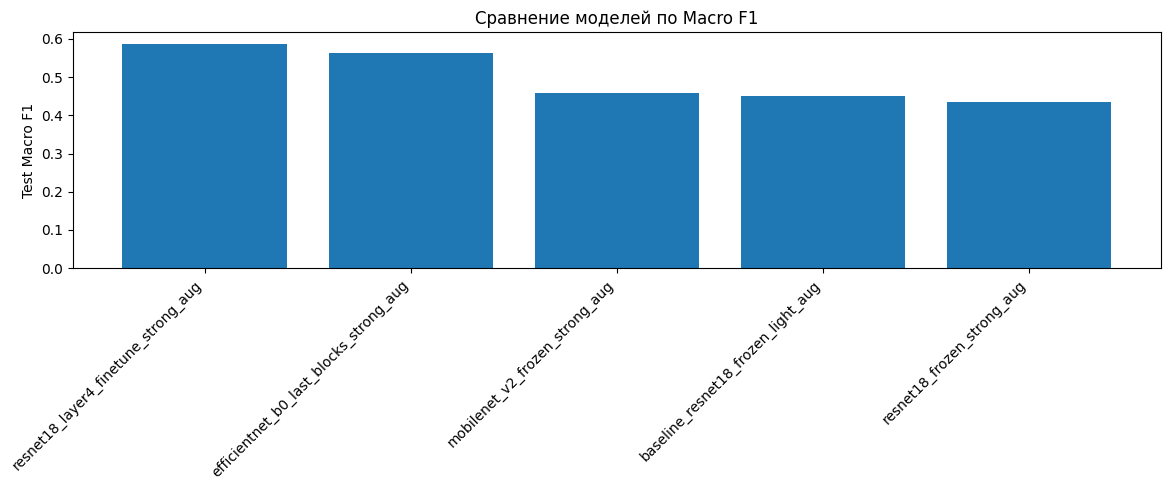

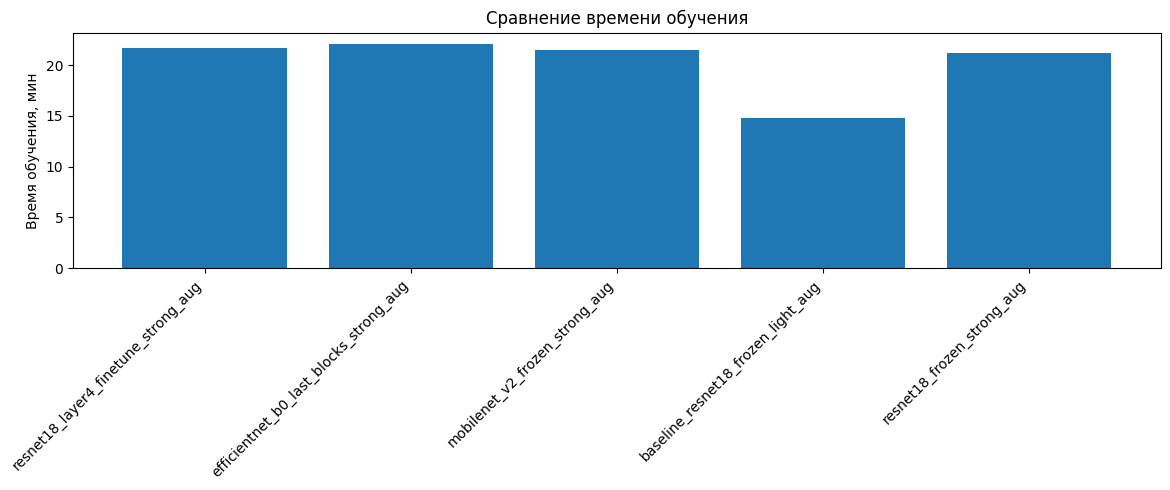

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["test_macro_f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Macro F1")
plt.title("Сравнение моделей по Macro F1")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "experiments_macro_f1.png", dpi=200)
plt.show()
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["train_time_min"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Время обучения, мин")
plt.title("Сравнение времени обучения")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "experiments_train_time.png", dpi=200)
plt.show()

## Кривые обучения лучшей модели

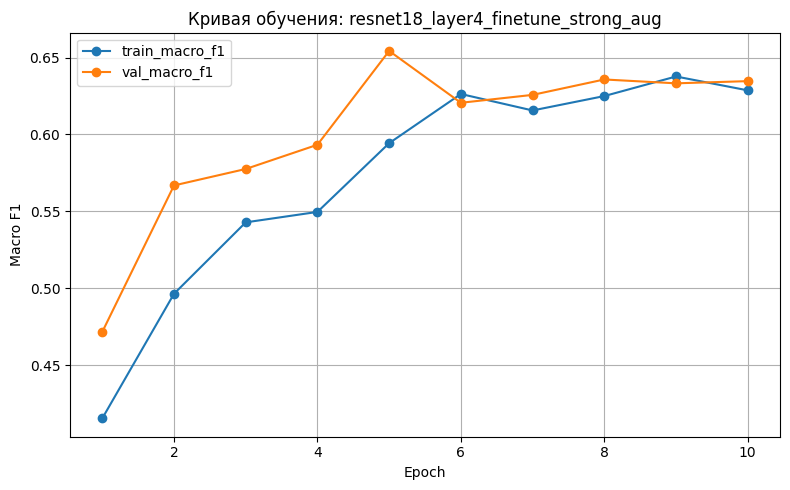

In [ ]:
best_exp = results_df.loc[0, "experiment"]
best_history = pd.read_csv(RESULTS_DIR / f"history_{best_exp}.csv")
plt.figure(figsize=(8, 5))
plt.plot(best_history["epoch"], best_history["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(best_history["epoch"], best_history["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title(f"Кривая обучения: {best_exp}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_model_learning_curve.png", dpi=200)
plt.show()

## Подробная оценка лучшей модели на test

  0%|          | 0/47 [00:00<?, ?it/s]

Best experiment: resnet18_layer4_finetune_strong_aug
Accuracy: 0.7438456420492349
Macro F1: 0.5879100248442608
ROC-AUC macro: 0.9369042757545901

              precision    recall  f1-score   support

       akiec       0.46      0.49      0.48        49
         bcc       0.41      0.87      0.56        77
         bkl       0.59      0.64      0.61       165
          df       0.40      0.59      0.48        17
         mel       0.43      0.54      0.48       167
          nv       0.96      0.80      0.87      1006
        vasc       0.50      0.91      0.65        22

    accuracy                           0.74      1503
   macro avg       0.54      0.69      0.59      1503
weighted avg       0.80      0.74      0.76      1503



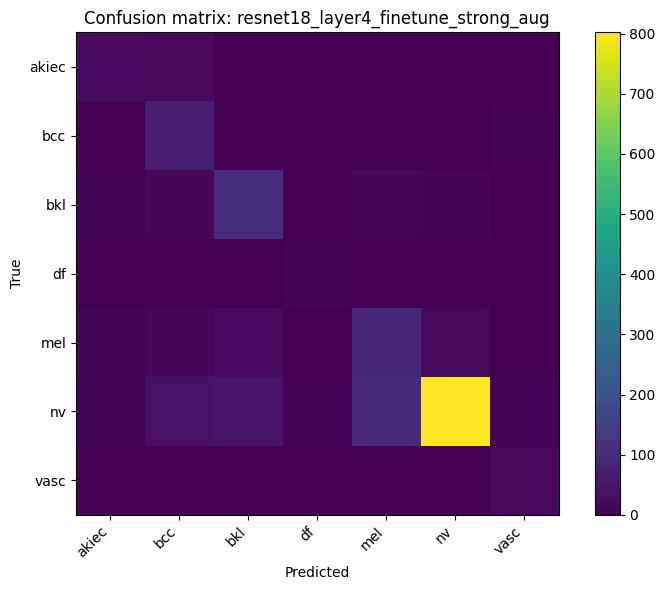

In [ ]:
best_row = results_df.iloc[0]
best_exp_name = best_row["experiment"]
best_config = next(exp for exp in experiments if exp["name"] == best_exp_name)
best_model = best_config["model_fn"]().to(DEVICE)
best_model.load_state_dict(torch.load(best_row["model_path"], map_location=DEVICE))
train_transform = light_train_transform if best_config["augmentation"] == "light" else strong_train_transform
_, _, test_loader = make_loaders(train_transform, batch_size=int(best_config["batch_size"]))
test_metrics = evaluate(best_model, test_loader, criterion, DEVICE)
print("Best experiment:", best_exp_name)
print("Accuracy:", test_metrics["accuracy"])
print("Macro F1:", test_metrics["macro_f1"])
print("ROC-AUC macro:", test_metrics["roc_auc_macro"])
print()
print(classification_report(test_metrics["targets"], test_metrics["preds"], target_names=classes))
cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion matrix: {best_exp_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_model_confusion_matrix.png", dpi=200)
plt.show()

## Выводы

Лучшее качество показал эксперимент resnet18_layer4_finetune_strong_aug.

По сравнению с baseline модель улучшила основные метрики:

| Модель | Accuracy | Macro F1 | ROC-AUC macro | Время обучения |
|---|---:|---:|---:|---:|
| Baseline ResNet-18 frozen + light aug | 0.6587 | 0.4509 | 0.9035 | 14.81 мин |
| ResNet-18 layer4 fine-tuning + strong aug | 0.7438 | 0.5879 | 0.9369 | 21.68 мин |

Прирост лучшей модели относительно baseline:

- Accuracy: +0.0851
- Macro F1: +0.1370
- ROC-AUC macro: +0.0334

Главный прирост получился не от простой замены аугментаций, а от fine-tuning последнего блока ResNet-18. Это логично: baseline обучал только финальный классификатор поверх замороженных ImageNet-признаков, а медицинские изображения кожи отличаются от ImageNet по текстурам, цветам и локальным визуальным паттернам. Разморозка layer4 позволила модели адаптировать высокоуровневые признаки под задачу классификации кожных новообразований.

Усиленные аугментации без fine-tuning не улучшили baseline: resnet18_frozen_strong_aug получил Macro F1 = 0.4356 против 0.4509 у baseline. Вероятно, при замороженном backbone модель не смогла достаточно хорошо адаптироваться к более сложным искажённым изображениям.

EfficientNet-B0 тоже показал хороший результат: Macro F1 = 0.5620, ROC-AUC macro = 0.9274. Однако он оказался немного слабее лучшего ResNet-18 fine-tuning и обучался немного дольше. MobileNetV2 оказался быстрее по числу обучаемых параметров, но по качеству заметно уступил лучшему решению.

Итог: лучшим решением является transfer learning на ResNet-18 с разморозкой последнего блока, class-weighted loss и strong augmentation.

## Краткое описание лучшего решения для отчёта

В качестве лучшего решения выбрана модель resnet18_layer4_finetune_strong_aug.

Решение использует предобученную на ImageNet архитектуру ResNet-18. Основная часть backbone заморожена, но последний блок layer4 разморожен и дообучается на медицинских изображениях. Финальный классификатор заменён на новый слой под 7 классов датасета. Для борьбы с дисбалансом классов используется CrossEntropyLoss с весами классов. Для увеличения устойчивости модели применяются аугментации: RandomResizedCrop, горизонтальные и вертикальные отражения, повороты и небольшое изменение яркости, контраста, насыщенности и оттенка.

Гиперпараметры лучшего эксперимента:

| Параметр | Значение |
|---|---:|
| Архитектура | ResNet-18 |
| Transfer learning | ImageNet pretrained weights |
| Дообучаемые слои | layer4 + final classifier |
| Аугментация | strong |
| Optimizer | AdamW |
| Learning rate | 3e-4 |
| Batch size | 32 |
| Epochs | 10 |
| Loss | Weighted CrossEntropyLoss |
| Test Accuracy | 0.7438 |
| Test Macro F1 | 0.5879 |
| Test ROC-AUC macro | 0.9369 |
| Время обучения | 21.68 мин |

Лучшее решение оказалось эффективнее baseline, потому что оно не только обучает новый классификатор, но и адаптирует последние признаки CNN к специфике медицинских изображений. Это особенно важно для датасета кожных новообразований, где классы различаются по мелким цветовым, текстурным и формальным признакам.
